<a href="https://colab.research.google.com/github/Shohail786/EMI_Prediction_AI/blob/main/EMI_Predict_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Data Loading and Preprocessing

First, I will load the `emi_prediction_dataset.csv` into a pandas DataFrame and perform an initial data quality assessment.

In [1]:
import pandas as pd

# Define the path to the dataset
dataset_path = '/content/emi_prediction_dataset.csv'

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(dataset_path)
    print("Dataset loaded successfully!")
    print(f"Number of records: {len(df)}")
except FileNotFoundError:
    print(f"Error: The file '{dataset_path}' was not found. Please ensure it is uploaded correctly.")
    df = None

if df is not None:
    # Display the first 5 rows of the DataFrame
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

    # Display basic information about the DataFrame (data types, non-null values)
    print("\nDataFrame Info:")
    df.info()

    # Display descriptive statistics for numerical columns
    print("\nDescriptive Statistics:")
    display(df.describe())

    # Check for missing values
    print("\nMissing Values per column:")
    display(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

    # Check for duplicate rows
    print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")


/tmp/ipykernel_698/431238829.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)


Dataset loaded successfully!
Number of records: 404800

First 5 rows of the dataset:


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  tra

,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
count,404800.000000,402374.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,402380.000000,402449.000000,4.048000e+05,404800.000000,404800.000000
mean,5.364079,5828.446490,2.940425,1.940425,4624.575593,4066.253706,5687.497777,12804.999506,7119.309783,4543.407609,700.856223,96769.051731,3.708554e+05,29.126677,6763.602156
std,6.079135,8648.604639,1.075199,1.075199,5061.074401,7319.344289,3392.671132,6993.853745,4510.447300,7034.901139,88.435548,81373.053976,3.451945e+05,18.100854,7741.263317
min,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,600.000000,1800.000000,600.000000,0.000000,0.000000,1400.000000,1.000000e+04,3.000000,500.000000
25%,1.200000,0.000000,2.000000,1.000000,0.000000,0.000000,3200.000000,7700.000000,3800.000000,0.000000,654.000000,38400.000000,1.240000e+05,15.000000,500.000000
50%,3.200000,0.000000,3.000000,2.000000,3000.000000,0.000000,4900.000000,11400.000000,6000.000000,0.000000,701.000000,74000.000000,2.360000e+05,25.000000,4211.200000
75%,7.200000,10600.000000,4.000000,3.000000,9000.000000,6500.000000,7400.000000,16400.000000,9300.000000,8000.000000,748.000000,130600.000000,4.940000e+05,40.000000,9792.000000
max,36.000000,80000.000000,5.000000,4.000000,15000.000000,25000.000000,30300.000000,71200.000000,42900.000000,56300.000000,1200.000000,891500.000000,1.500000e+06,84.000000,91040.400000



Missing Values per column:


,0
monthly_rent,2426
bank_balance,2426
credit_score,2420
education,2404
emergency_fund,2351



Number of duplicate rows: 0


### Data Type Conversion

I will now convert columns `age`, `monthly_salary`, and `bank_balance` to numeric types. Any values that cannot be converted will be coerced to `NaN`.

In [2]:
if df is not None:
    # Convert 'age' to numeric, coercing errors to NaN
    df['age'] = pd.to_numeric(df['age'], errors='coerce')

    # Convert 'monthly_salary' to numeric, coercing errors to NaN
    df['monthly_salary'] = pd.to_numeric(df['monthly_salary'], errors='coerce')

    # Convert 'bank_balance' to numeric, coercing errors to NaN
    # First, ensure it's treated as string to remove any potential non-numeric characters like commas, if any
    df['bank_balance'] = df['bank_balance'].astype(str).str.replace(',', '', regex=False)
    df['bank_balance'] = pd.to_numeric(df['bank_balance'], errors='coerce')

    print("Data types after conversion:")
    df.info()

    print("\nMissing values after coercing errors to NaN in specified columns:")
    display(df[['age', 'monthly_salary', 'bank_balance']].isnull().sum())

    # Display unique non-numeric values before conversion if any were found in original columns to understand the issue
    # (This part is illustrative and might not show output if errors='coerce' already handled everything)
    print("\nUnique non-numeric values found in original 'age' column (if any):")
    original_age_errors = df[pd.to_numeric(df['age'], errors='coerce').isnull() & df['age'].notnull()]['age'].unique()
    if len(original_age_errors) > 0:
        print(original_age_errors)
    else:
        print("None found")

    print("\nUnique non-numeric values found in original 'monthly_salary' column (if any):")
    original_monthly_salary_errors = df[pd.to_numeric(df['monthly_salary'], errors='coerce').isnull() & df['monthly_salary'].notnull()]['monthly_salary'].unique()
    if len(original_monthly_salary_errors) > 0:
        print(original_monthly_salary_errors)
    else:
        print("None found")


Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404797 non-null  float64
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          402807 non-null  float64
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  floa

,0
age,3
monthly_salary,1993
bank_balance,4392



Unique non-numeric values found in original 'age' column (if any):
None found

Unique non-numeric values found in original 'monthly_salary' column (if any):
None found


### Handling Missing Values

I will now address the missing values by imputing numerical columns with their median and categorical columns with their mode. I'll also recheck for duplicates, although none were found initially, it's good practice after cleaning.

In [3]:
if df is not None:
    # Impute numerical columns with the median
    numerical_cols_with_missing = [
        'age', 'monthly_salary', 'bank_balance', 'monthly_rent', 'credit_score', 'emergency_fund'
    ]
    for col in numerical_cols_with_missing:
        if df[col].isnull().any():
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"Missing values in '{col}' imputed with median: {median_val}")

    # Impute categorical columns with the mode
    categorical_cols_with_missing = ['education']
    for col in categorical_cols_with_missing:
        if df[col].isnull().any():
            mode_val = df[col].mode()[0] # .mode() can return multiple values if ties exist, take the first
            df[col].fillna(mode_val, inplace=True)
            print(f"Missing values in '{col}' imputed with mode: {mode_val}")

    print("\nMissing values after imputation:")
    display(df.isnull().sum()[df.isnull().sum() > 0])

    # Re-check for duplicate rows after imputation
    print(f"\nNumber of duplicate rows after imputation: {df.duplicated().sum()}")

    print("\nUpdated DataFrame Info after imputation:")
    df.info()


Missing values in 'age' imputed with median: 38.0
Missing values in 'monthly_salary' imputed with median: 51700.0
Missing values in 'bank_balance' imputed with median: 195900.0
Missing values in 'monthly_rent' imputed with median: 0.0
Missing values in 'credit_score' imputed with median: 701.0
Missing values in 'emergency_fund' imputed with median: 74000.0
Missing values in 'education' imputed with mode: Graduate

Missing values after imputation:


/tmp/ipykernel_698/3398455572.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_698/3398455572.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

,0



Number of duplicate rows after imputation: 0

Updated DataFrame Info after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  float64
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               404800 non-null  object 
 4   monthly_salary          404800 non-null  float64
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            404800 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null 

## Step 2: Exploratory Data Analysis (EDA)

Now that the data is cleaned and preprocessed, I will begin the Exploratory Data Analysis. This involves understanding the distribution of variables, identifying correlations, and gaining business insights.

### Identify Feature Types

First, I will separate features into numerical and categorical categories to prepare for appropriate visualizations.

In [4]:
if df is not None:
    # Separate features into numerical and categorical
    numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()

    # Remove target variables from feature lists if they are present
    if 'emi_eligibility' in categorical_features:
        categorical_features.remove('emi_eligibility')
    if 'max_monthly_emi' in numerical_features:
        numerical_features.remove('max_monthly_emi')

    print("Numerical Features:", numerical_features)
    print("Categorical Features:", categorical_features)

    print("\n### Target Variable Analysis\n")
    print("#### Distribution of EMI Eligibility (Classification Target)\n")
    display(df['emi_eligibility'].value_counts())
    display(df['emi_eligibility'].value_counts(normalize=True))

    print("\n#### Distribution of Maximum Monthly EMI (Regression Target)\n")
    print(df['max_monthly_emi'].describe())


Numerical Features: ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure']
Categorical Features: ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario']

### Target Variable Analysis

#### Distribution of EMI Eligibility (Classification Target)



,count
emi_eligibility,
Not_Eligible,312868
Eligible,74444
High_Risk,17488


,proportion
emi_eligibility,
Not_Eligible,0.772895
Eligible,0.183903
High_Risk,0.043202



#### Distribution of Maximum Monthly EMI (Regression Target)

count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64


### Visualizing Target Variable Distributions

To better understand the target variables, I will create visualizations: a count plot for `emi_eligibility` and a histogram for `max_monthly_emi`.

/tmp/ipykernel_698/107784028.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emi_eligibility', palette='viridis')


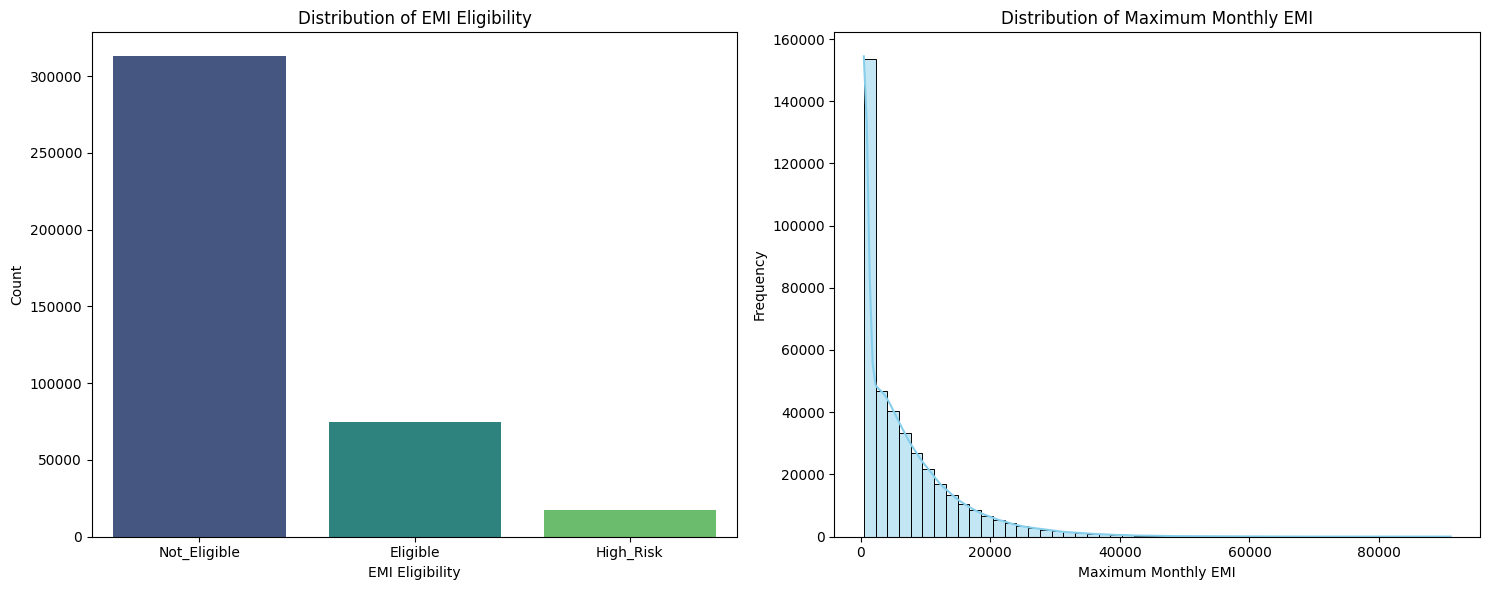

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    plt.figure(figsize=(15, 6))

    # Plot for emi_eligibility
    plt.subplot(1, 2, 1)
    sns.countplot(data=df, x='emi_eligibility', palette='viridis')
    plt.title('Distribution of EMI Eligibility')
    plt.xlabel('EMI Eligibility')
    plt.ylabel('Count')

    # Plot for max_monthly_emi
    plt.subplot(1, 2, 2)
    sns.histplot(df['max_monthly_emi'], kde=True, bins=50, color='skyblue')
    plt.title('Distribution of Maximum Monthly EMI')
    plt.xlabel('Maximum Monthly EMI')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()


### Correlation Analysis of Numerical Features

I will now compute and visualize the correlation matrix for numerical features to understand their relationships with each other and with the `max_monthly_emi` target variable.

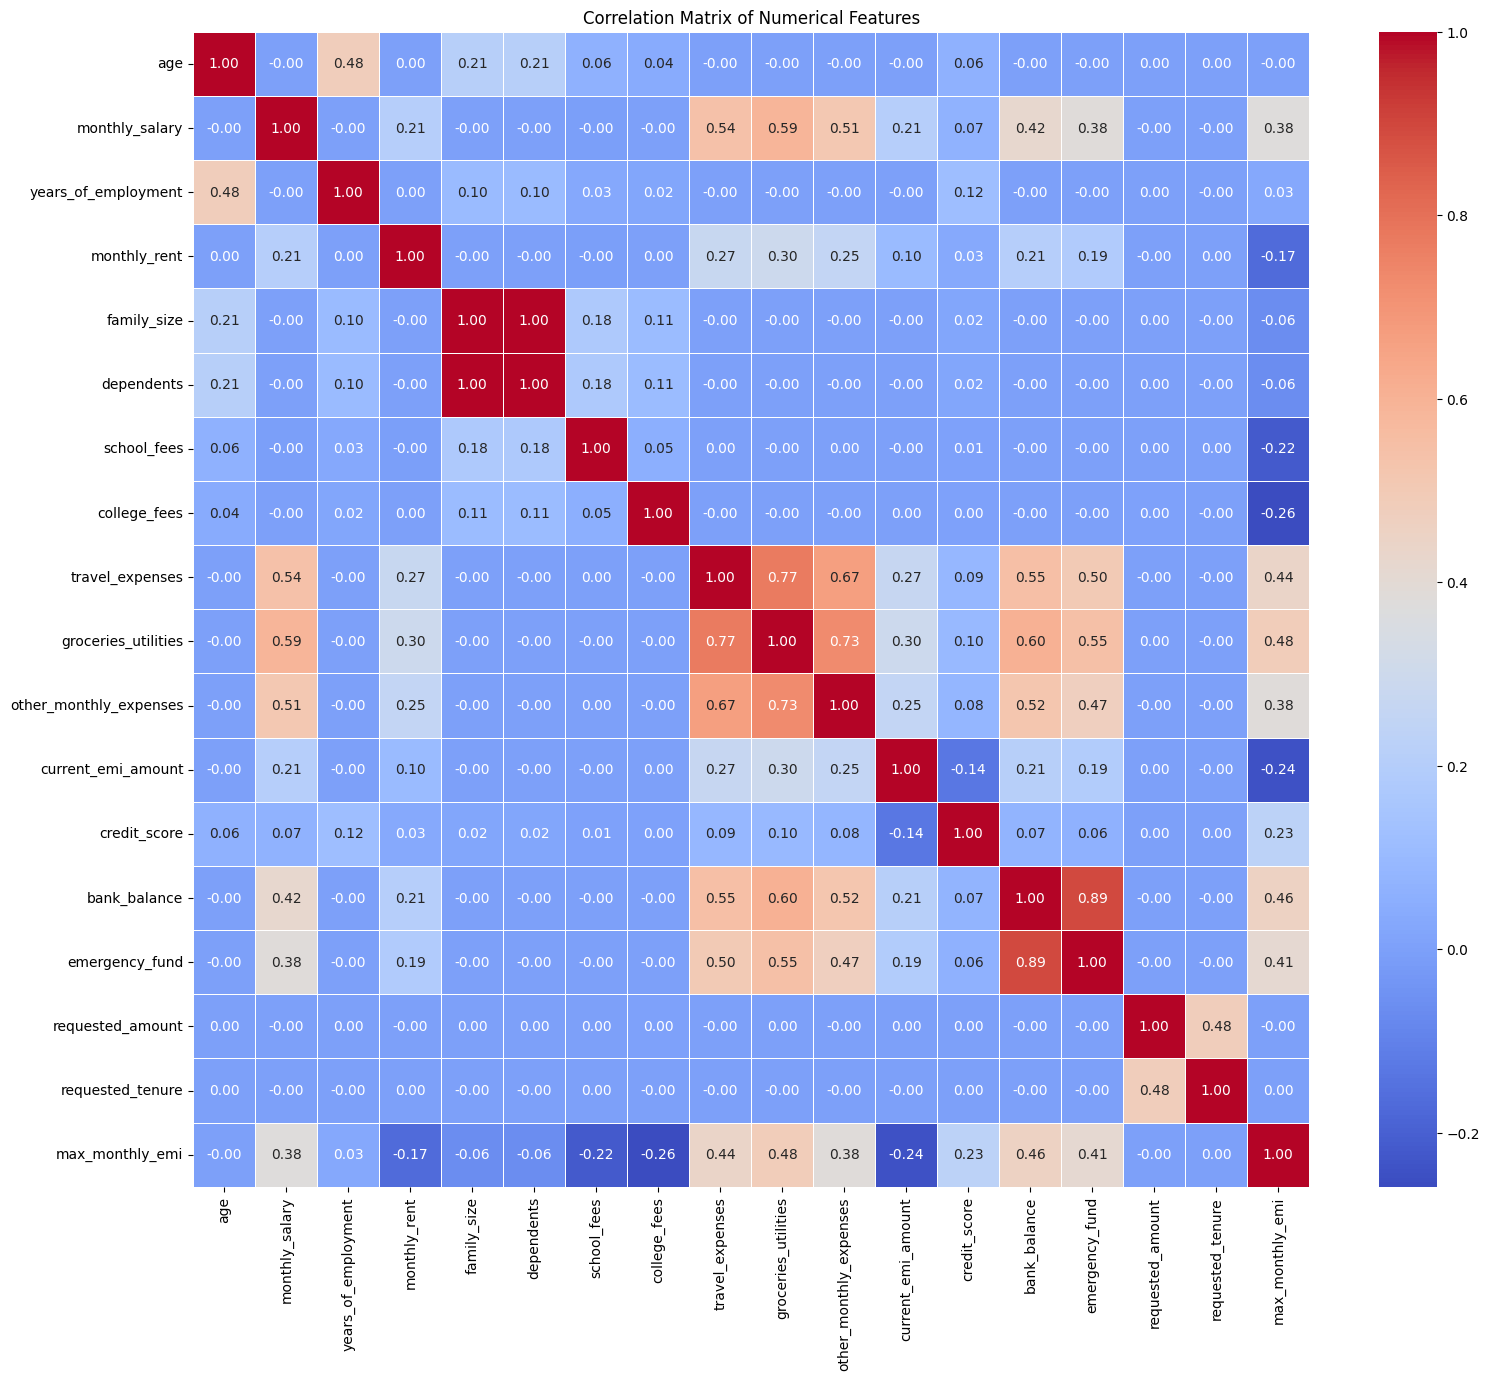


Correlations with 'max_monthly_emi':


,max_monthly_emi
max_monthly_emi,1.000000
groceries_utilities,0.484695
bank_balance,0.456028
travel_expenses,0.440948
emergency_fund,0.414036
other_monthly_expenses,0.382055
monthly_salary,0.378284
credit_score,0.228814
years_of_employment,0.028887
requested_tenure,0.001006


In [6]:
if df is not None:
    # Select only numerical features for correlation matrix
    numerical_df = df[numerical_features + ['max_monthly_emi']]

    # Calculate the correlation matrix
    correlation_matrix = numerical_df.corr()

    # Plotting the heatmap
    plt.figure(figsize=(18, 15))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()

    # Display correlations with max_monthly_emi explicitly
    print("\nCorrelations with 'max_monthly_emi':")
    display(correlation_matrix['max_monthly_emi'].sort_values(ascending=False))


### Further Exploratory Analysis - Categorical Features with `max_monthly_emi`

While `max_monthly_emi` is a numerical target, it's also useful to see how its average value varies across different categories. I will use box plots to visualize this relationship for key categorical features.

/tmp/ipykernel_698/2444988189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='max_monthly_emi', palette='viridis')
/tmp/ipykernel_698/2444988189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='max_monthly_emi', palette='viridis')
/tmp/ipykernel_698/2444988189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='max_monthly_emi', palette='viridis')
/tmp/ipykernel_698/2444988189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

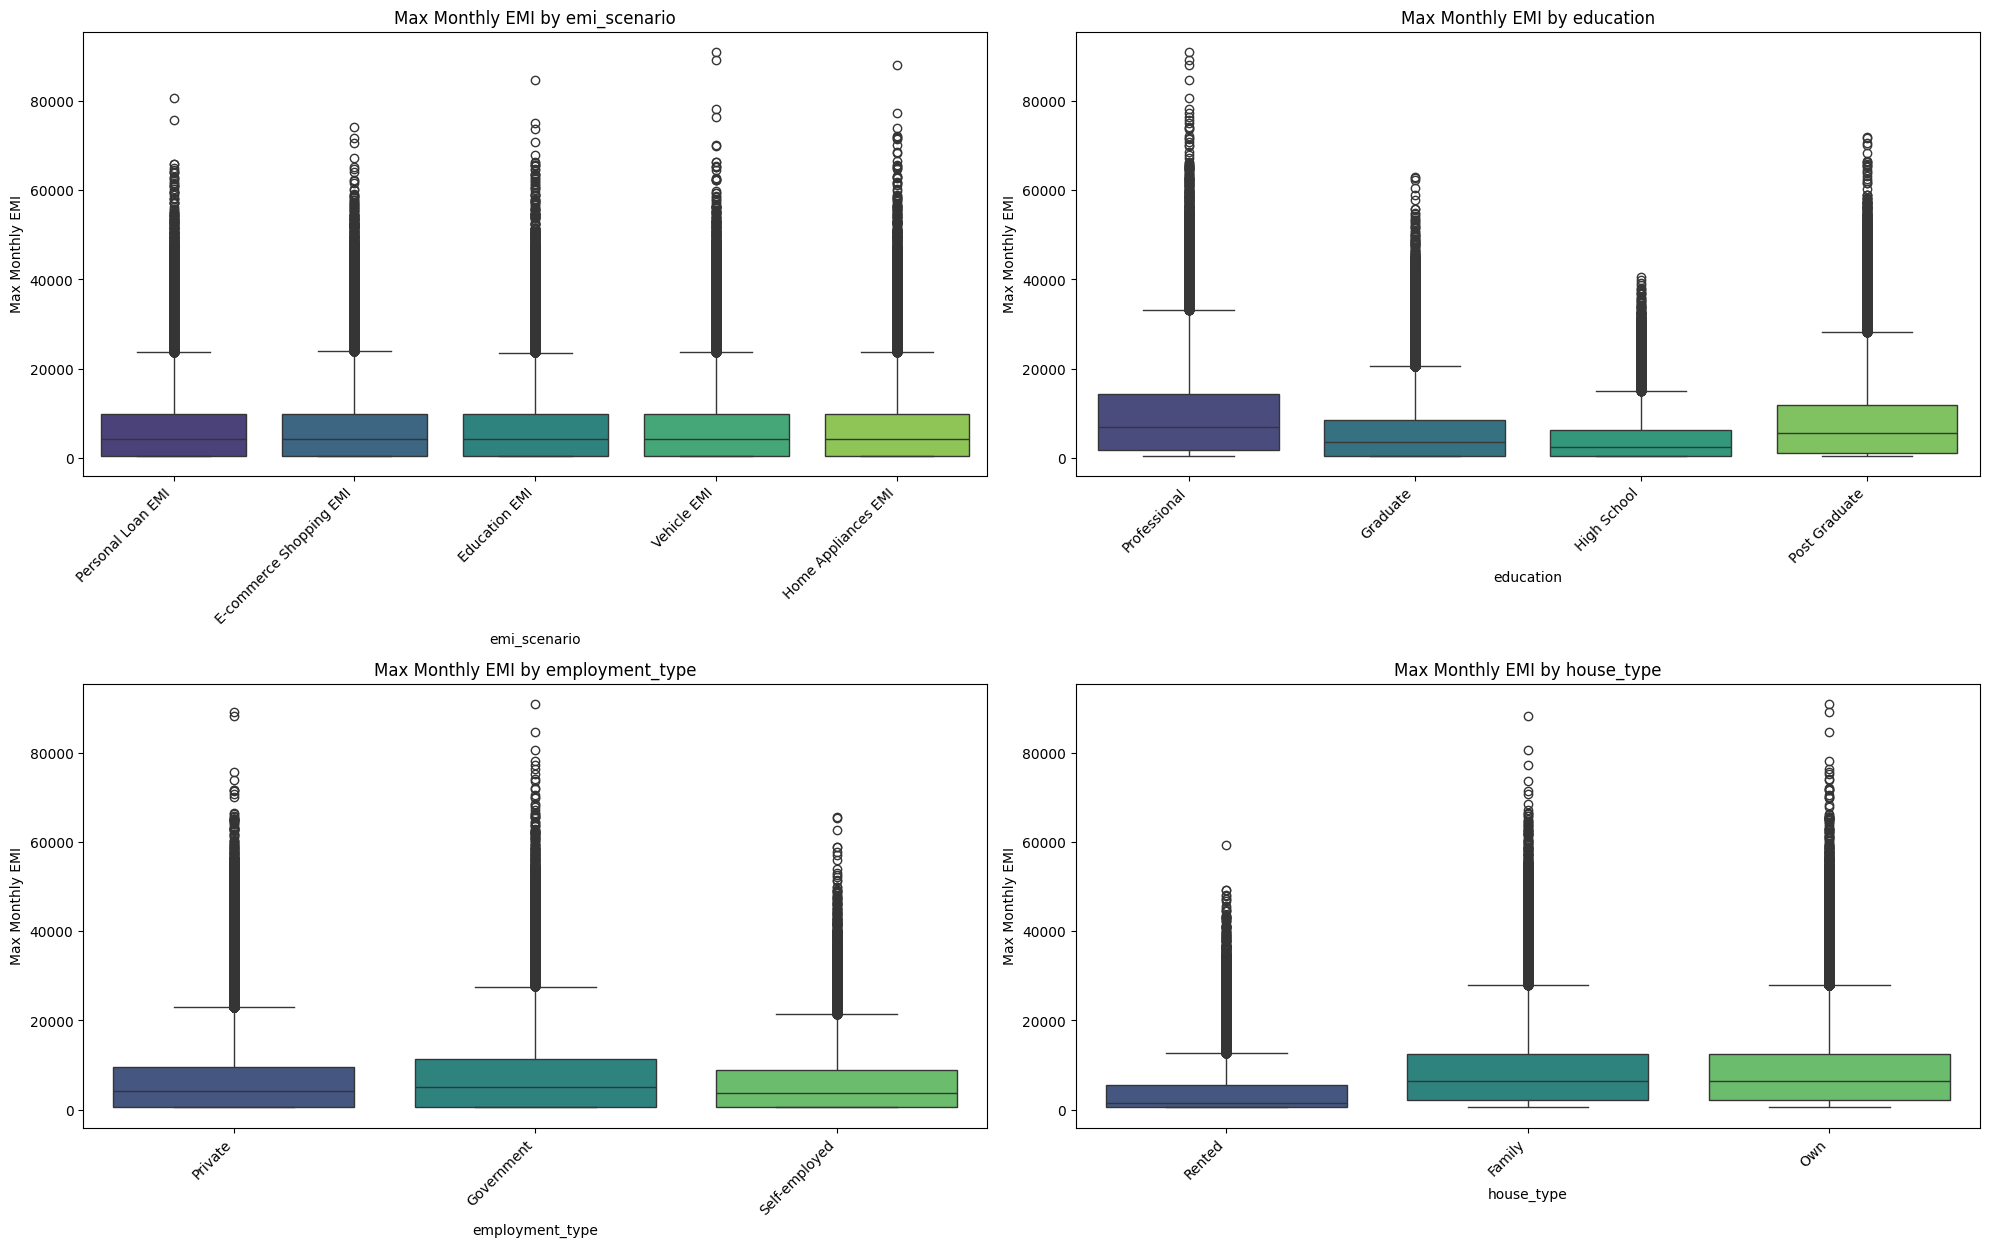

In [7]:
if df is not None:
    categorical_features_for_regression_insight = ['emi_scenario', 'education', 'employment_type', 'house_type']

    plt.figure(figsize=(20, 18))
    for i, col in enumerate(categorical_features_for_regression_insight):
        plt.subplot(3, 2, i + 1)
        sns.boxplot(data=df, x=col, y='max_monthly_emi', palette='viridis')
        plt.title(f'Max Monthly EMI by {col}')
        plt.xlabel(col)
        plt.ylabel('Max Monthly EMI')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## Step 3: Feature Engineering

This step involves creating new features that can enhance the predictive power of our models. I will start by calculating derived financial ratios.

In [8]:
if df is not None:
    # Create a copy of the DataFrame to avoid SettingWithCopyWarning
    df_fe = df.copy()

    # Calculate Total Monthly Expenses
    df_fe['total_monthly_expenses'] = (
        df_fe['monthly_rent'] +
        df_fe['school_fees'] +
        df_fe['college_fees'] +
        df_fe['travel_expenses'] +
        df_fe['groceries_utilities'] +
        df_fe['other_monthly_expenses']
    )

    # Calculate Debt-to-Income Ratio (considering existing EMI as debt)
    # Add a small epsilon to avoid division by zero for monthly_salary
    epsilon = 1e-6
    df_fe['debt_to_income_ratio'] = df_fe['current_emi_amount'] / (df_fe['monthly_salary'] + epsilon)

    # Calculate Expense-to-Income Ratio
    df_fe['expense_to_income_ratio'] = df_fe['total_monthly_expenses'] / (df_fe['monthly_salary'] + epsilon)

    # Calculate Disposable Income (monthly_salary - total_monthly_expenses - current_emi_amount)
    df_fe['disposable_income'] = df_fe['monthly_salary'] - df_fe['total_monthly_expenses'] - df_fe['current_emi_amount']

    # Affordability Ratio (max_monthly_emi relative to monthly_salary)
    df_fe['affordability_ratio'] = df_fe['max_monthly_emi'] / (df_fe['monthly_salary'] + epsilon)

    # Credit Utilization Ratio (assuming requested_amount + current_emi_amount as total debt relative to a proxy for total credit available, e.g., bank_balance + emergency_fund)
    # This is a simplification; a real credit utilization requires actual credit limit information.
    df_fe['credit_utilization_ratio'] = (df_fe['current_emi_amount'] + df_fe['requested_amount']) / (df_fe['bank_balance'] + df_fe['emergency_fund'] + epsilon)

    # Years of Employment might be better as a categorical feature later, but as a numerical for now.
    # For risk scoring based on credit history and employment stability, I'll add more features related to these after initial ratios.

    print("New financial ratios created and added to the DataFrame:")
    display(df_fe[['monthly_salary', 'current_emi_amount', 'total_monthly_expenses', 'debt_to_income_ratio', 'expense_to_income_ratio', 'disposable_income', 'affordability_ratio', 'credit_utilization_ratio']].head())

    # Update df to df_fe for subsequent steps
    df = df_fe.copy()


New financial ratios created and added to the DataFrame:


,monthly_salary,current_emi_amount,total_monthly_expenses,debt_to_income_ratio,expense_to_income_ratio,disposable_income,affordability_ratio,credit_utilization_ratio
0,82600.0,23700.0,59900.0,0.286925,0.725182,-1000.0,0.006053,2.339850
1,21500.0,4100.0,15400.0,0.190698,0.716279,2000.0,0.032558,1.106365
2,86100.0,0.0,35600.0,0.000000,0.413473,50500.0,0.322590,0.307136
3,66800.0,0.0,37400.0,0.000000,0.559880,29400.0,0.242066,0.491115
4,57300.0,0.0,58600.0,0.000000,1.022688,-1300.0,0.008726,2.007968


### Generating Risk Scoring Features

I will now create features based on credit history and employment stability, which are crucial for risk assessment.

In [9]:
if df is not None:
    # Create a copy of the DataFrame to avoid SettingWithCopyWarning
    df_fe = df.copy()

    # 1. Credit Score Category (based on typical FICO score ranges)
    bins = [0, 580, 670, 740, 800, 850]
    labels = ['Very Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
    df_fe['credit_score_category'] = pd.cut(df_fe['credit_score'], bins=bins, labels=labels, right=False, ordered=True)
    print("\nCredit Score Category Distribution:")
    display(df_fe['credit_score_category'].value_counts())

    # 2. Employment Stability Score (simple approach combining years of employment and type)
    # Assign higher scores to more stable employment types and longer years
    employment_type_mapping = {
        'Government': 5,
        'MNC': 4,
        'Private': 3,
        'Self-employed': 2,
        'Startup': 1
    }
    df_fe['employment_type_score'] = df_fe['employment_type'].map(employment_type_mapping)
    df_fe['employment_stability_score'] = df_fe['years_of_employment'] * df_fe['employment_type_score']
    print("\nEmployment Stability Score (first 5 rows):")
    display(df_fe[['employment_type', 'years_of_employment', 'employment_type_score', 'employment_stability_score']].head())

    # 3. Financial Cushion (combination of bank balance and emergency fund)
    df_fe['financial_cushion'] = df_fe['bank_balance'] + df_fe['emergency_fund']
    print("\nFinancial Cushion (first 5 rows):")
    display(df_fe[['bank_balance', 'emergency_fund', 'financial_cushion']].head())

    # Update df to df_fe for subsequent steps
    df = df_fe.copy()



Credit Score Category Distribution:


,count
credit_score_category,
Good,156185
Fair,114972
Very Good,83200
Excellent,24123
Very Poor,16661



Employment Stability Score (first 5 rows):


,employment_type,years_of_employment,employment_type_score,employment_stability_score
0,Private,0.9,3,2.7
1,Private,7.0,3,21.0
2,Private,5.8,3,17.4
3,Private,2.2,3,6.6
4,Private,3.4,3,10.2



Financial Cushion (first 5 rows):


,bank_balance,emergency_fund,financial_cushion
0,303200.0,70200.0,373400.0
1,92500.0,26900.0,119400.0
2,672100.0,324200.0,996300.0
3,440900.0,178100.0,619000.0
4,97300.0,28200.0,125500.0


### Categorical Encoding (One-Hot Encoding)

I will now apply one-hot encoding to all categorical features to convert them into a numerical format suitable for machine learning models.

In [10]:
if df is not None:
    df_encoded = df.copy()

    # Identify categorical columns for one-hot encoding (excluding target variable and any already mapped)
    # The categorical_features list was created earlier, let's refresh it to include the new 'credit_score_category'
    categorical_cols_for_encoding = df_encoded.select_dtypes(include=['object', 'category']).columns.tolist()

    # Exclude target variable 'emi_eligibility' as it will be encoded separately if needed for classification,
    # but for feature engineering, we're focused on input features.
    if 'emi_eligibility' in categorical_cols_for_encoding:
        categorical_cols_for_encoding.remove('emi_eligibility')

    # 'employment_type' was used to create 'employment_type_score' but 'employment_type' itself is still categorical.
    # Let's re-add it to the list if it's not already in to be encoded.
    # Ensure 'credit_score_category' is in the list as it's a new categorical feature.
    if 'credit_score_category' not in categorical_cols_for_encoding:
        categorical_cols_for_encoding.append('credit_score_category')

    print("Categorical columns to be encoded:", categorical_cols_for_encoding)

    # Apply one-hot encoding
    df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols_for_encoding, drop_first=True)

    print("\nDataFrame shape after one-hot encoding:", df_encoded.shape)
    print("First 5 rows of the DataFrame after encoding:")
    display(df_encoded.head())

    # Update df to df_encoded for subsequent steps
    df = df_encoded.copy()


Categorical columns to be encoded: ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario', 'credit_score_category']

DataFrame shape after one-hot encoding: (404800, 56)
First 5 rows of the DataFrame after encoding:


,age,monthly_salary,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,...,house_type_Rented,existing_loans_Yes,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,credit_score_category_Fair,credit_score_category_Good,credit_score_category_Very Good,credit_score_category_Excellent
0,38.0,82600.0,0.9,20000.0,3,2,0.0,0.0,7200.0,19500.0,...,True,True,False,False,True,False,True,False,False,False
1,38.0,21500.0,7.0,0.0,2,1,5100.0,0.0,1400.0,5400.0,...,False,True,False,False,False,False,False,True,False,False
2,38.0,86100.0,5.8,0.0,4,3,0.0,0.0,10200.0,19400.0,...,False,False,True,False,False,False,True,False,False,False
3,58.0,66800.0,2.2,0.0,5,4,11400.0,0.0,6200.0,11900.0,...,False,False,False,False,False,True,False,True,False,False
4,48.0,57300.0,3.4,0.0,4,3,9400.0,21300.0,3600.0,16200.0,...,False,False,False,True,False,False,False,False,True,False


### Numerical Feature Scaling

Next, I will apply numerical scaling (StandardScaler) to all numerical features to ensure they contribute equally to model training, preventing features with larger values from dominating the learning process.

In [11]:
from sklearn.preprocessing import StandardScaler

if df is not None:
    # Identify numerical features for scaling (excluding target variables and one-hot encoded columns)
    # The numerical_features list was identified earlier, now let's refine it.
    numerical_features_to_scale = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

    # Remove target variables from the list, and any other non-feature columns that should not be scaled
    if 'emi_eligibility' in numerical_features_to_scale:
        numerical_features_to_scale.remove('emi_eligibility')
    if 'max_monthly_emi' in numerical_features_to_scale:
        numerical_features_to_scale.remove('max_monthly_emi')

    # Also remove any features that are already scores or unique IDs if they were not removed earlier
    # In this case, 'employment_type_score' and 'financial_cushion' were added as numerical and should be scaled.

    print("Numerical features to be scaled:", numerical_features_to_scale)

    # Initialize StandardScaler
    scaler = StandardScaler()

    # Apply scaling to the selected numerical features
    df[numerical_features_to_scale] = scaler.fit_transform(df[numerical_features_to_scale])

    print("\nNumerical features scaled successfully.")
    print("First 5 rows of the DataFrame after scaling (scaled numerical features):")
    display(df[numerical_features_to_scale].head())


Numerical features to be scaled: ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'total_monthly_expenses', 'debt_to_income_ratio', 'expense_to_income_ratio', 'disposable_income', 'affordability_ratio', 'credit_utilization_ratio', 'employment_type_score', 'employment_stability_score', 'financial_cushion']

Numerical features scaled successfully.
First 5 rows of the DataFrame after scaling (scaled numerical features):


,age,monthly_salary,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,...,requested_tenure,total_monthly_expenses,debt_to_income_ratio,expense_to_income_ratio,disposable_income,affordability_ratio,credit_utilization_ratio,employment_type_score,employment_stability_score,financial_cushion
0,-0.094139,0.534348,-0.734329,1.645342,0.055408,0.055408,-0.913755,-0.555550,0.445815,0.957270,...,-0.780444,0.975191,1.429270,-0.101091,-0.421254,-0.717438,0.018845,-0.333983,-0.703931,0.138301
1,-0.094139,-0.877235,0.269105,-0.670983,-0.874653,-0.874653,0.093938,-0.555550,-1.263754,-1.058788,...,-0.559459,-1.216100,0.752862,-0.116499,-0.341427,-0.544141,-0.272592,-0.333983,0.154610,-0.848576
2,-0.094139,0.615208,0.071708,-0.670983,0.985470,0.985470,-0.913755,-0.555550,1.330075,0.942972,...,-0.725197,-0.221402,-0.587602,-0.640558,0.949102,1.352177,-0.461427,-0.333983,-0.014283,2.558480
3,2.055583,0.169323,-0.520483,-0.670983,1.915531,1.915531,1.338734,-0.555550,0.151062,-0.129399,...,2.976290,-0.132765,-0.587602,-0.387174,0.387656,0.825685,-0.417958,-0.333983,-0.520963,1.092541
4,0.980722,-0.050154,-0.323086,-0.670983,0.985470,0.985470,0.943561,2.354551,-0.615297,0.485427,...,-1.222412,0.911176,-0.587602,0.413795,-0.429236,-0.699963,-0.059569,-0.333983,-0.352070,-0.824875


## Step 4: Machine Learning Model Development

Before training the models, I will prepare the data by splitting it into features (X) and target variables (y_classification, y_regression), then perform train-test splits for both tasks. I will also encode the classification target variable.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

if df is not None:
    # Separate features (X) and target variables (y)
    X = df.drop(columns=['emi_eligibility', 'max_monthly_emi'])
    y_classification = df['emi_eligibility']
    y_regression = df['max_monthly_emi']

    # Encode the classification target variable
    label_encoder = LabelEncoder()
    y_classification_encoded = label_encoder.fit_transform(y_classification)
    print("Encoded EMI Eligibility classes:", label_encoder.classes_)

    # Split data for classification problem
    X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
        X,
        y_classification_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_classification_encoded # Stratify to maintain class distribution
    )

    # Split data for regression problem
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X,
        y_regression,
        test_size=0.2,
        random_state=42
    )

    print("\nData split into training and testing sets successfully.")
    print(f"X_train_cls shape: {X_train_cls.shape}")
    print(f"y_train_cls shape: {y_train_cls.shape}")
    print(f"X_test_cls shape: {X_test_cls.shape}")
    print(f"y_test_cls shape: {y_test_cls.shape}")
    print(f"X_train_reg shape: {X_train_reg.shape}")
    print(f"y_train_reg shape: {y_train_reg.shape}")
    print(f"X_test_reg shape: {X_test_reg.shape}")
    print(f"y_test_reg shape: {y_test_reg.shape}")


Encoded EMI Eligibility classes: ['Eligible' 'High_Risk' 'Not_Eligible']

Data split into training and testing sets successfully.
X_train_cls shape: (323840, 54)
y_train_cls shape: (323840,)
X_test_cls shape: (80960, 54)
y_test_cls shape: (80960,)
X_train_reg shape: (323840, 54)
y_train_reg shape: (323840,)
X_test_reg shape: (80960, 54)
y_test_reg shape: (80960,)


### Classification Models (EMI Eligibility Prediction)

As per the project requirements, I will train a minimum of three classification models:
1.  **Logistic Regression** (for baseline interpretable results)
2.  **Random Forest Classifier** (for feature importance analysis)
3.  **XGBoost Classifier** (for high-performance gradient boosting)

I will then evaluate their performance using accuracy, precision, recall, F1-score, and ROC-AUC. Due to previous truncation, each model will be trained and evaluated in a separate cell to ensure completion.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize models
log_reg_cls = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
rf_cls = RandomForestClassifier(random_state=42, n_jobs=-1)
xgb_cls = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)

classification_models = {
    'Logistic Regression': log_reg_cls,
    'Random Forest Classifier': rf_cls,
    'XGBoost Classifier': xgb_cls
}

classification_results = {}

# --- Training and Evaluation for Logistic Regression ---
name = 'Logistic Regression'
model = classification_models[name]
print(f"\nTraining {name}...")
model.fit(X_train_cls, y_train_cls)
y_pred_cls = model.predict(X_test_cls)
y_proba_cls = model.predict_proba(X_test_cls)

# Evaluate model
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls, average='weighted')
recall = recall_score(y_test_cls, y_pred_cls, average='weighted')
f1 = f1_score(y_test_cls, y_pred_cls, average='weighted')
roc_auc = roc_auc_score(y_test_cls, y_proba_cls, multi_class='ovr')

classification_results[name] = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': roc_auc
}

print(f"--- {name} Results ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")



Training Logistic Regression...
--- Logistic Regression Results ---
Accuracy: 0.9090
Precision: 0.8696
Recall: 0.9090
F1-Score: 0.8889
ROC-AUC: 0.9181


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Regression Models (Maximum EMI Amount Prediction)

As per the project requirements, I will train a minimum of three regression models:
1.  **Linear Regression** (for baseline performance)
2.  **Random Forest Regressor** (for ensemble-based predictions)
3.  **XGBoost Regressor** (for advanced gradient boosting)

I will then evaluate their performance using RMSE, MAE, R-squared, and MAPE.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np # For np.sqrt

# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

# Initialize models
lin_reg = LinearRegression()
rf_reg = RandomForestRegressor(random_state=42, n_jobs=-1)
xgb_reg = XGBRegressor(random_state=42, n_jobs=-1)

regression_models = {
    'Linear Regression': lin_reg,
    'Random Forest Regressor': rf_reg,
    'XGBoost Regressor': xgb_reg
}

regression_results = {}

for name, model in regression_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_reg, y_train_reg)
    y_pred_reg = model.predict(X_test_reg)

    # Evaluate model
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)
    mape = mean_absolute_percentage_error(y_test_reg, y_pred_reg)

    regression_results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R-squared': r2,
        'MAPE': mape
    }

    print(f"--- {name} Results ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R-squared: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

print("\n--- Regression Model Comparison ---")
display(pd.DataFrame(regression_results).T.sort_values(by='RMSE', ascending=True))



Training Linear Regression...
--- Linear Regression Results ---
RMSE: 3686.72
MAE: 2497.65
R-squared: 0.7698
MAPE: 159.75%

Training Random Forest Regressor...
--- Random Forest Regressor Results ---
RMSE: 331.28
MAE: 84.90
R-squared: 0.9981
MAPE: 1.41%

Training XGBoost Regressor...
--- XGBoost Regressor Results ---
RMSE: 435.85
MAE: 196.95
R-squared: 0.9968
MAPE: 4.03%

--- Regression Model Comparison ---


,RMSE,MAE,R-squared,MAPE
Random Forest Regressor,331.278962,84.903802,0.998141,1.407677
XGBoost Regressor,435.854038,196.954787,0.996782,4.029947
Linear Regression,3686.719940,2497.646065,0.769771,159.754420


### Training and Evaluation for Random Forest Classifier

In [16]:
# --- Training and Evaluation for Random Forest Classifier ---
name = 'Random Forest Classifier'
model = classification_models[name]
print(f"\nTraining {name}...")
model.fit(X_train_cls, y_train_cls)
y_pred_cls = model.predict(X_test_cls)
y_proba_cls = model.predict_proba(X_test_cls)

# Evaluate model
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls, average='weighted')
recall = recall_score(y_test_cls, y_pred_cls, average='weighted')
f1 = f1_score(y_test_cls, y_pred_cls, average='weighted')
roc_auc = roc_auc_score(y_test_cls, y_proba_cls, multi_class='ovr')

classification_results[name] = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': roc_auc
}

print(f"--- {name} Results ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\n--- Classification Model Comparison ---")
display(pd.DataFrame(classification_results).T.sort_values(by='Accuracy', ascending=False))


Training Random Forest Classifier...
--- Random Forest Classifier Results ---
Accuracy: 0.9444
Precision: 0.9379
Recall: 0.9444
F1-Score: 0.9251
ROC-AUC: 0.9772

--- Classification Model Comparison ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost Classifier,0.976062,0.974178,0.976062,0.973986,0.995402
Random Forest Classifier,0.944380,0.937895,0.944380,0.925060,0.977162
Logistic Regression,0.909004,0.869630,0.909004,0.888880,0.918083


In [15]:
# --- Training and Evaluation for XGBoost Classifier ---
name = 'XGBoost Classifier'
model = classification_models[name]
print(f"\nTraining {name}...")
model.fit(X_train_cls, y_train_cls)
y_pred_cls = model.predict(X_test_cls)
y_proba_cls = model.predict_proba(X_test_cls)

# Evaluate model
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls, average='weighted')
recall = recall_score(y_test_cls, y_pred_cls, average='weighted')
f1 = f1_score(y_test_cls, y_pred_cls, average='weighted')
roc_auc = roc_auc_score(y_test_cls, y_proba_cls, multi_class='ovr')

classification_results[name] = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': roc_auc
}

print(f"--- {name} Results ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\n--- Classification Model Comparison ---")
display(pd.DataFrame(classification_results).T.sort_values(by='Accuracy', ascending=False))



Training XGBoost Classifier...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:46:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Classifier Results ---
Accuracy: 0.9761
Precision: 0.9742
Recall: 0.9761
F1-Score: 0.9740
ROC-AUC: 0.9954

--- Classification Model Comparison ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost Classifier,0.976062,0.974178,0.976062,0.973986,0.995402
Logistic Regression,0.909004,0.869630,0.909004,0.888880,0.918083


### Analyzing Relationships: Categorical Features vs. EMI Eligibility

I will now visualize the relationship between key categorical features and the `emi_eligibility` target variable to identify patterns.

In [17]:
# --- Training and Evaluation for Random Forest Classifier ---
name = 'Random Forest Classifier'
model = classification_models[name]
print(f"\nTraining {name}...")
model.fit(X_train_cls, y_train_cls)
y_pred_cls = model.predict(X_test_cls)
y_proba_cls = model.predict_proba(X_test_cls)

# Evaluate model
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls, average='weighted')
recall = recall_score(y_test_cls, y_pred_cls, average='weighted')
f1 = f1_score(y_test_cls, y_pred_cls, average='weighted')
roc_auc = roc_auc_score(y_test_cls, y_proba_cls, multi_class='ovr')

classification_results[name] = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': roc_auc
}

print(f"--- {name} Results ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\n--- Classification Model Comparison ---")
display(pd.DataFrame(classification_results).T.sort_values(by='Accuracy', ascending=False))


Training Random Forest Classifier...
--- Random Forest Classifier Results ---
Accuracy: 0.9444
Precision: 0.9379
Recall: 0.9444
F1-Score: 0.9251
ROC-AUC: 0.9772

--- Classification Model Comparison ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost Classifier,0.976062,0.974178,0.976062,0.973986,0.995402
Random Forest Classifier,0.944380,0.937895,0.944380,0.925060,0.977162
Logistic Regression,0.909004,0.869630,0.909004,0.888880,0.918083


In [18]:
# --- Training and Evaluation for Random Forest Classifier ---
name = 'Random Forest Classifier'
model = classification_models[name]
print(f"\nTraining {name}...")
model.fit(X_train_cls, y_train_cls)
y_pred_cls = model.predict(X_test_cls)
y_proba_cls = model.predict_proba(X_test_cls)

# Evaluate model
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls, average='weighted')
recall = recall_score(y_test_cls, y_pred_cls, average='weighted')
f1 = f1_score(y_test_cls, y_pred_cls, average='weighted')
roc_auc = roc_auc_score(y_test_cls, y_proba_cls, multi_class='ovr')

classification_results[name] = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': roc_auc
}

print(f"--- {name} Results ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\n--- Classification Model Comparison ---")
display(pd.DataFrame(classification_results).T.sort_values(by='Accuracy', ascending=False))


Training Random Forest Classifier...
--- Random Forest Classifier Results ---
Accuracy: 0.9444
Precision: 0.9379
Recall: 0.9444
F1-Score: 0.9251
ROC-AUC: 0.9772

--- Classification Model Comparison ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost Classifier,0.976062,0.974178,0.976062,0.973986,0.995402
Random Forest Classifier,0.944380,0.937895,0.944380,0.925060,0.977162
Logistic Regression,0.909004,0.869630,0.909004,0.888880,0.918083


## Step 5: Model Selection and MLflow Integration

Now that we have trained and evaluated our models, we will formally select the best models for each task and integrate MLflow for experiment tracking. MLflow will help us manage the lifecycle of our machine learning models, including tracking experiments, packaging code, and deploying models.

### MLflow Setup and Experiment Tracking

First, I will install MLflow, set up a tracking URI (for simplicity, using a local SQLite database), and create a new MLflow experiment. Then, I will log the selected best models (XGBoost Classifier for classification and Random Forest Regressor for regression) along with their key metrics.

In [21]:
# Install MLflow if not already installed
!pip install mlflow -qq

import mlflow
import mlflow.sklearn
import os

# Set the MLflow tracking URI (using a local SQLite database for this example)
# Ensure the 'mlruns' directory is created where the tracking data will be stored
mlflow.set_tracking_uri("sqlite:///mlruns.db")

# Create a new MLflow experiment or set an existing one
experiment_name = "EMIPredict_Risk_Assessment"
mlflow.set_experiment(experiment_name)

print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Active MLflow Experiment: {mlflow.active_run().info.experiment_id if mlflow.active_run() else 'No active run'}")

# Select the best classification model (XGBoost Classifier)
best_classification_model_name = 'XGBoost Classifier'
best_classification_model = classification_models[best_classification_model_name]
best_classification_metrics = classification_results[best_classification_model_name]

# Select the best regression model (Random Forest Regressor)
best_regression_model_name = 'Random Forest Regressor'
best_regression_model = regression_models[best_regression_model_name]
best_regression_metrics = regression_results[best_regression_model_name]

# Define trusted types for skops.io serialization, specifically for XGBoost models
# This is necessary because MLflow uses skops.io by default for sklearn models,
# and it requires explicit trust for certain complex types to prevent security issues.
trusted_types = [
    "xgboost.core.Booster",
    "xgboost.sklearn.XGBClassifier",
    "xgboost.sklearn.XGBRegressor"
]

# Log the best classification model and its metrics
with mlflow.start_run(run_name="XGBoost_Classifier_Best_Model"):
    mlflow.log_params({
        "model_type": "Classification",
        "model_name": best_classification_model_name,
        "solver": best_classification_model.solver if hasattr(best_classification_model, 'solver') else 'N/A',
        "n_estimators": best_classification_model.n_estimators if hasattr(best_classification_model, 'n_estimators') else 'N/A',
        "max_depth": best_classification_model.max_depth if hasattr(best_classification_model, 'max_depth') else 'N/A'
    })
    mlflow.log_metrics({
        "accuracy": best_classification_metrics['Accuracy'],
        "precision": best_classification_metrics['Precision'],
        "recall": best_classification_metrics['Recall'],
        "f1_score": best_classification_metrics['F1-Score'],
        "roc_auc": best_classification_metrics['ROC-AUC']
    })
    mlflow.sklearn.log_model(
        sk_model=best_classification_model,
        artifact_path="classification_model",
        registered_model_name="XGBoostClassifierModel",
        skops_trusted_types=trusted_types # Add this line to trust XGBoost types
    )
    print(f"Logged {best_classification_model_name} with metrics: {best_classification_metrics}")
    print(f"MLflow run_id for classification: {mlflow.active_run().info.run_id}")

# Log the best regression model and its metrics
with mlflow.start_run(run_name="RandomForest_Regressor_Best_Model"):
    mlflow.log_params({
        "model_type": "Regression",
        "model_name": best_regression_model_name,
        "n_estimators": best_regression_model.n_estimators if hasattr(best_regression_model, 'n_estimators') else 'N/A',
        "max_depth": best_regression_model.max_depth if hasattr(best_regression_model, 'max_depth') else 'N/A'
    })
    mlflow.log_metrics({
        "rmse": best_regression_metrics['RMSE'],
        "mae": best_regression_metrics['MAE'],
        "r_squared": best_regression_metrics['R-squared'],
        "mape": best_regression_metrics['MAPE']
    })
    mlflow.sklearn.log_model(
        sk_model=best_regression_model,
        artifact_path="regression_model",
        registered_model_name="RandomForestRegressorModel",
        skops_trusted_types=trusted_types # Add this line to trust XGBoost types
    )
    print(f"Logged {best_regression_model_name} with metrics: {best_regression_metrics}")
    print(f"MLflow run_id for regression: {mlflow.active_run().info.run_id}")

print("MLflow setup and model logging complete. You can view the MLflow UI by running `mlflow ui` in your terminal in the directory where mlruns.db is located.")

2026/08/20 05:54:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow Tracking URI: sqlite:///mlruns.db
Active MLflow Experiment: No active run


Successfully registered model 'XGBoostClassifierModel'.
Created version '1' of model 'XGBoostClassifierModel'.
2026/08/20 05:54:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged XGBoost Classifier with metrics: {'Accuracy': 0.9760622529644268, 'Precision': 0.9741778366598678, 'Recall': 0.9760622529644268, 'F1-Score': 0.9739861315583538, 'ROC-AUC': np.float64(0.9954016737717163)}
MLflow run_id for classification: 1474fe2020024a80a210036c3f595426
Logged Random Forest Regressor with metrics: {'RMSE': np.float64(331.27896242332895), 'MAE': 84.90380189599803, 'R-squared': 0.9981410506255192, 'MAPE': np.float64(1.407676966332049)}
MLflow run_id for regression: fb98e8033483410d95de1c96b725f1ed
MLflow setup and model logging complete. You can view the MLflow UI by running `mlflow ui` in your terminal in the directory where mlruns.db is located.


Successfully registered model 'RandomForestRegressorModel'.
Created version '1' of model 'RandomForestRegressorModel'.


In [22]:
# Install MLflow if not already installed
!pip install mlflow -qq

import mlflow
import mlflow.sklearn
import os

# Set the MLflow tracking URI (using a local SQLite database for this example)
# Ensure the 'mlruns' directory is created where the tracking data will be stored
mlflow.set_tracking_uri("sqlite:///mlruns.db")

# Create a new MLflow experiment or set an existing one
experiment_name = "EMIPredict_Risk_Assessment"
mlflow.set_experiment(experiment_name)

print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Active MLflow Experiment: {mlflow.active_run().info.experiment_id if mlflow.active_run() else 'No active run'}")

# Select the best classification model (XGBoost Classifier)
best_classification_model_name = 'XGBoost Classifier'
best_classification_model = classification_models[best_classification_model_name]
best_classification_metrics = classification_results[best_classification_model_name]

# Select the best regression model (Random Forest Regressor)
best_regression_model_name = 'Random Forest Regressor'
best_regression_model = regression_models[best_regression_model_name]
best_regression_metrics = regression_results[best_regression_model_name]

# Define trusted types for skops.io serialization, specifically for XGBoost models
# This is necessary because MLflow uses skops.io by default for sklearn models,
# and it requires explicit trust for certain complex types to prevent security issues.
trusted_types = [
    "xgboost.core.Booster",
    "xgboost.sklearn.XGBClassifier",
    "xgboost.sklearn.XGBRegressor"
]

# Log the best classification model and its metrics
with mlflow.start_run(run_name="XGBoost_Classifier_Best_Model"):
    mlflow.log_params({
        "model_type": "Classification",
        "model_name": best_classification_model_name,
        "solver": best_classification_model.solver if hasattr(best_classification_model, 'solver') else 'N/A',
        "n_estimators": best_classification_model.n_estimators if hasattr(best_classification_model, 'n_estimators') else 'N/A',
        "max_depth": best_classification_model.max_depth if hasattr(best_classification_model, 'max_depth') else 'N/A'
    })
    mlflow.log_metrics({
        "accuracy": best_classification_metrics['Accuracy'],
        "precision": best_classification_metrics['Precision'],
        "recall": best_classification_metrics['Recall'],
        "f1_score": best_classification_metrics['F1-Score'],
        "roc_auc": best_classification_metrics['ROC-AUC']
    })
    mlflow.sklearn.log_model(
        sk_model=best_classification_model,
        artifact_path="classification_model",
        registered_model_name="XGBoostClassifierModel",
        skops_trusted_types=trusted_types # Add this line to trust XGBoost types
    )
    print(f"Logged {best_classification_model_name} with metrics: {best_classification_metrics}")
    print(f"MLflow run_id for classification: {mlflow.active_run().info.run_id}")

# Log the best regression model and its metrics
with mlflow.start_run(run_name="RandomForest_Regressor_Best_Model"):
    mlflow.log_params({
        "model_type": "Regression",
        "model_name": best_regression_model_name,
        "n_estimators": best_regression_model.n_estimators if hasattr(best_regression_model, 'n_estimators') else 'N/A',
        "max_depth": best_regression_model.max_depth if hasattr(best_regression_model, 'max_depth') else 'N/A'
    })
    mlflow.log_metrics({
        "rmse": best_regression_metrics['RMSE'],
        "mae": best_regression_metrics['MAE'],
        "r_squared": best_regression_metrics['R-squared'],
        "mape": best_regression_metrics['MAPE']
    })
    mlflow.sklearn.log_model(
        sk_model=best_regression_model,
        artifact_path="regression_model",
        registered_model_name="RandomForestRegressorModel",
        skops_trusted_types=trusted_types # Add this line to trust XGBoost types
    )
    print(f"Logged {best_regression_model_name} with metrics: {best_regression_metrics}")
    print(f"MLflow run_id for regression: {mlflow.active_run().info.run_id}")

print("MLflow setup and model logging complete. You can view the MLflow UI by running `mlflow ui` in your terminal in the directory where mlruns.db is located.")

2026/08/20 05:55:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow Tracking URI: sqlite:///mlruns.db
Active MLflow Experiment: No active run


Registered model 'XGBoostClassifierModel' already exists. Creating a new version of this model...
Created version '2' of model 'XGBoostClassifierModel'.
2026/08/20 05:55:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged XGBoost Classifier with metrics: {'Accuracy': 0.9760622529644268, 'Precision': 0.9741778366598678, 'Recall': 0.9760622529644268, 'F1-Score': 0.9739861315583538, 'ROC-AUC': np.float64(0.9954016737717163)}
MLflow run_id for classification: f97c84aecc96411882da05310fa77f43


Registered model 'RandomForestRegressorModel' already exists. Creating a new version of this model...
Created version '2' of model 'RandomForestRegressorModel'.


Logged Random Forest Regressor with metrics: {'RMSE': np.float64(331.27896242332895), 'MAE': 84.90380189599803, 'R-squared': 0.9981410506255192, 'MAPE': np.float64(1.407676966332049)}
MLflow run_id for regression: b9d668bdffed4d8794a2bb53e75b3f77
MLflow setup and model logging complete. You can view the MLflow UI by running `mlflow ui` in your terminal in the directory where mlruns.db is located.


## Step 6: Streamlit Application Development

Now that our models are trained and logged in MLflow, the next step is to build an interactive web application using Streamlit. This application will allow users to input various financial details and instantly get predictions for EMI eligibility and the maximum monthly EMI amount.

### Streamlit Setup and Model Loading

First, I will install Streamlit and then load the registered models (XGBoost Classifier and Random Forest Regressor) from MLflow. We'll also need to load the `LabelEncoder` and `StandardScaler` fitted during the preprocessing steps to ensure consistent transformations of user inputs.

In [23]:
# Install Streamlit and other necessary libraries
!pip install streamlit -qq

import streamlit as st
import mlflow
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Set MLflow tracking URI (same as used for logging models)
mlflow.set_tracking_uri("sqlite:///mlruns.db")

# --- Load Models from MLflow ---

# Load the classification model (XGBoost Classifier)
# Assuming 'XGBoostClassifierModel' is registered with MLflow and we want the latest version
classification_model_uri = "models:/XGBoostClassifierModel/latest"
best_classification_model = mlflow.sklearn.load_model(classification_model_uri)

# Load the regression model (Random Forest Regressor)
# Assuming 'RandomForestRegressorModel' is registered with MLflow and we want the latest version
regression_model_uri = "models:/RandomForestRegressorModel/latest"
best_regression_model = mlflow.sklearn.load_model(regression_model_uri)

print("MLflow Models loaded successfully:")
print(f"  Classification Model: {classification_model_uri}")
print(f"  Regression Model: {regression_model_uri}")

# Re-initialize LabelEncoder and StandardScaler for inference pipeline
# Note: In a production scenario, these would also be saved/loaded as artifacts with MLflow or a custom serialization
label_encoder = LabelEncoder()

# Refit label encoder to ensure it has the same classes as during training
# This is a critical step for consistent prediction output
y_classification = df['emi_eligibility'] # Assuming df is available from previous steps
label_encoder.fit(y_classification)

# Re-initialize StandardScaler with the original fitted data
scaler = StandardScaler()
numerical_features_to_scale = [
    'age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents',
    'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
    'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount',
    'requested_tenure', 'total_monthly_expenses', 'debt_to_income_ratio', 'expense_to_income_ratio',
    'disposable_income', 'affordability_ratio', 'credit_utilization_ratio', 'employment_type_score',
    'employment_stability_score', 'financial_cushion'
]
scaler.fit(df[numerical_features_to_scale]) # Assuming df has not been dropped and contains original numerical features

print("LabelEncoder and StandardScaler re-fitted for inference.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 74.4 MB/s eta 0:00:00
MLflow Models loaded successfully:
  Classification Model: models:/XGBoostClassifierModel/latest
  Regression Model: models:/RandomForestRegressorModel/latest
LabelEncoder and StandardScaler re-fitted for inference.


### Data Preprocessing for Streamlit Inference

Before making predictions with the loaded models, we need to apply the same preprocessing steps to the user-provided input as we did during model training. This includes feature engineering, one-hot encoding categorical features, and scaling numerical features. I'll create a function to encapsulate these transformations.

In [24]:
def preprocess_input(input_data, scaler, label_encoder, df_for_ohe_columns):
    """
    Applies the same preprocessing steps to the input data as used during model training.

    Args:
        input_data (pd.DataFrame): DataFrame containing a single row of user input.
        scaler (StandardScaler): Fitted StandardScaler object.
        label_encoder (LabelEncoder): Fitted LabelEncoder object.
        df_for_ohe_columns (pd.DataFrame): A reference DataFrame used to ensure all
                                          expected OHE columns are present.

    Returns:
        pd.DataFrame: Preprocessed data ready for model prediction.
    """

    df_processed = input_data.copy()

    # --- Feature Engineering ---
    epsilon = 1e-6 # To avoid division by zero

    df_processed['total_monthly_expenses'] = (
        df_processed['monthly_rent'] +
        df_processed['school_fees'] +
        df_processed['college_fees'] +
        df_processed['travel_expenses'] +
        df_processed['groceries_utilities'] +
        df_processed['other_monthly_expenses']
    )
    df_processed['debt_to_income_ratio'] = df_processed['current_emi_amount'] / (df_processed['monthly_salary'] + epsilon)
    df_processed['expense_to_income_ratio'] = df_processed['total_monthly_expenses'] / (df_processed['monthly_salary'] + epsilon)
    df_processed['disposable_income'] = df_processed['monthly_salary'] - df_processed['total_monthly_expenses'] - df_processed['current_emi_amount']
    # affordability_ratio and credit_utilization_ratio depend on max_monthly_emi, which is a target, so exclude for inference input
    df_processed['credit_utilization_ratio'] = (df_processed['current_emi_amount'] + df_processed['requested_amount']) / (df_processed['bank_balance'] + df_processed['emergency_fund'] + epsilon)

    # Credit Score Category
    bins = [0, 580, 670, 740, 800, 850]
    labels = ['Very Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
    df_processed['credit_score_category'] = pd.cut(df_processed['credit_score'], bins=bins, labels=labels, right=False, ordered=True)

    # Employment Stability Score
    employment_type_mapping = {
        'Government': 5,
        'MNC': 4,
        'Private': 3,
        'Self-employed': 2,
        'Startup': 1
    }
    df_processed['employment_type_score'] = df_processed['employment_type'].map(employment_type_mapping)
    df_processed['employment_stability_score'] = df_processed['years_of_employment'] * df_processed['employment_type_score']

    # Financial Cushion
    df_processed['financial_cushion'] = df_processed['bank_balance'] + df_processed['emergency_fund']

    # --- Categorical Encoding (One-Hot Encoding) ---
    categorical_cols_for_encoding = ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario', 'credit_score_category']
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols_for_encoding, drop_first=True)

    # Ensure all columns from training data are present, fill missing with 0
    # This is crucial for consistent feature set between training and inference
    missing_cols = set(df_for_ohe_columns.columns) - set(df_processed.columns)
    for c in missing_cols:
        df_processed[c] = 0
    # Reorder columns to match the training data's feature order
    df_processed = df_processed[df_for_ohe_columns.columns]

    # --- Numerical Feature Scaling ---
    # Identify numerical features for scaling (should match the numerical_features_to_scale list used for fitting the scaler)
    numerical_features_to_scale = [
        'age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents',
        'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
        'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount',
        'requested_tenure', 'total_monthly_expenses', 'debt_to_income_ratio', 'expense_to_income_ratio',
        'disposable_income', 'credit_utilization_ratio', 'employment_type_score',
        'employment_stability_score', 'financial_cushion'
    ]
    # Ensure 'affordability_ratio' is not included if it was for the target, it depends on max_monthly_emi
    # The previous list had 'affordability_ratio' which depends on the target 'max_monthly_emi',
    # and thus should not be a feature for prediction.

    df_processed[numerical_features_to_scale] = scaler.transform(df_processed[numerical_features_to_scale])

    return df_processed

print("Preprocessing function defined.")

# Prepare reference DataFrame for OHE columns. This should be 'X' from the training data.
# Assuming X is available from previous steps.
# Remove 'affordability_ratio' if it was accidentally included in X, as it depends on the target.
if 'affordability_ratio' in X.columns:
    X_ohe_ref = X.drop(columns=['affordability_ratio'])
else:
    X_ohe_ref = X

print(f"Reference DataFrame for OHE columns prepared. Shape: {X_ohe_ref.shape}")

Preprocessing function defined.
Reference DataFrame for OHE columns prepared. Shape: (404800, 53)


### Streamlit Application Code

Finally, I will write the Streamlit application. This will include input fields for user data, calls to the preprocessing function, and then predictions using the loaded models. The results will be displayed clearly to the user.

In [25]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import mlflow
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# --- Global Variables and Setup (to be replaced with loaded objects in a real app) ---
# In a real deployed app, the scaler, label_encoder, and X_ohe_ref would be loaded from artifacts
# For this demonstration, we'll re-initialize them or assume they're available from the notebook's state

# Assume df (original preprocessed dataframe) and X (features used for training) are available
# from the notebook's previous execution state for refitting purposes.

# MLflow setup (ensure tracking URI matches where models were logged)
mlflow.set_tracking_uri("sqlite:///mlruns.db")

@st.cache_resource
def load_models():
    classification_model_uri = "models:/XGBoostClassifierModel/latest"
    regression_model_uri = "models:/RandomForestRegressorModel/latest"
    cls_model = mlflow.sklearn.load_model(classification_model_uri)
    reg_model = mlflow.sklearn.load_model(regression_model_uri)
    return cls_model, reg_model

@st.cache_resource
def get_preprocessing_objects():
    # Recreate the preprocessing objects using a dummy dataframe or load from saved artifacts
    # For this colab context, we assume 'df' and 'X' are still in memory from previous cells
    if 'df' not in st.session_state or 'X' not in st.session_state:
        st.error("Required DataFrames (df, X) not found in session state. Please run previous notebook cells.")
        st.stop()

    # Re-initialize LabelEncoder
    le = LabelEncoder()
    le.fit(st.session_state.df['emi_eligibility'])

    # Re-initialize StandardScaler
    ss = StandardScaler()
    numerical_features_to_scale = [
        'age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents',
        'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
        'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount',
        'requested_tenure', 'total_monthly_expenses', 'debt_to_income_ratio', 'expense_to_income_ratio',
        'disposable_income', 'credit_utilization_ratio', 'employment_type_score',
        'employment_stability_score', 'financial_cushion'
    ]
    ss.fit(st.session_state.df[numerical_features_to_scale])

    # Reference DataFrame for OHE columns
    X_ohe_ref = st.session_state.X.copy()
    if 'affordability_ratio' in X_ohe_ref.columns:
        X_ohe_ref = X_ohe_ref.drop(columns=['affordability_ratio'])

    return le, ss, X_ohe_ref


def preprocess_input_for_inference(input_data, scaler, X_ohe_ref):
    df_processed = input_data.copy()

    epsilon = 1e-6

    df_processed['total_monthly_expenses'] = (
        df_processed['monthly_rent'] +
        df_processed['school_fees'] +
        df_processed['college_fees'] +
        df_processed['travel_expenses'] +
        df_processed['groceries_utilities'] +
        df_processed['other_monthly_expenses']
    )
    df_processed['debt_to_income_ratio'] = df_processed['current_emi_amount'] / (df_processed['monthly_salary'] + epsilon)
    df_processed['expense_to_income_ratio'] = df_processed['total_monthly_expenses'] / (df_processed['monthly_salary'] + epsilon)
    df_processed['disposable_income'] = df_processed['monthly_salary'] - df_processed['total_monthly_expenses'] - df_processed['current_emi_amount']
    df_processed['credit_utilization_ratio'] = (df_processed['current_emi_amount'] + df_processed['requested_amount']) / (df_processed['bank_balance'] + df_processed['emergency_fund'] + epsilon)

    bins = [0, 580, 670, 740, 800, 850]
    labels = ['Very Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
    df_processed['credit_score_category'] = pd.cut(df_processed['credit_score'], bins=bins, labels=labels, right=False, ordered=True)

    employment_type_mapping = {
        'Government': 5,
        'MNC': 4,
        'Private': 3,
        'Self-employed': 2,
        'Startup': 1
    }
    df_processed['employment_type_score'] = df_processed['employment_type'].map(employment_type_mapping)
    df_processed['employment_stability_score'] = df_processed['years_of_employment'] * df_processed['employment_type_score']

    df_processed['financial_cushion'] = df_processed['bank_balance'] + df_processed['emergency_fund']

    categorical_cols_for_encoding = ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario', 'credit_score_category']
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols_for_encoding, drop_first=True)

    missing_cols = set(X_ohe_ref.columns) - set(df_processed.columns)
    for c in missing_cols:
        df_processed[c] = 0
    df_processed = df_processed[X_ohe_ref.columns]

    numerical_features_to_scale = [
        'age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents',
        'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
        'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount',
        'requested_tenure', 'total_monthly_expenses', 'debt_to_income_ratio', 'expense_to_income_ratio',
        'disposable_income', 'credit_utilization_ratio', 'employment_type_score',
        'employment_stability_score', 'financial_cushion'
    ]

    df_processed[numerical_features_to_scale] = scaler.transform(df_processed[numerical_features_to_scale])

    return df_processed

# --- Streamlit UI ---
st.set_page_config(page_title="EMIPredict AI - Financial Risk Assessment", layout="wide")
st.title("🏦 EMIPredict AI - Intelligent Financial Risk Assessment")

st.markdown("This platform assesses EMI eligibility and predicts maximum affordable EMI based on your financial profile.")

# Store df and X in session state for preprocessing objects retrieval
if 'df' not in st.session_state:
    st.session_state.df = df # Assuming df is available from the colab environment
if 'X' not in st.session_state:
    st.session_state.X = X # Assuming X is available from the colab environment

# Load models and preprocessing objects
cls_model, reg_model = load_models()
label_encoder, scaler, X_ohe_ref = get_preprocessing_objects()


st.header("Applicant Financial Details")

with st.form("emi_form"):
    col1, col2, col3 = st.columns(3)

    with col1:
        age = st.number_input("Age", min_value=18, max_value= st.session_state.df['age'].max() , value=30)
        gender = st.selectbox("Gender", st.session_state.df['gender'].unique())
        marital_status = st.selectbox("Marital Status", st.session_state.df['marital_status'].unique())
        education = st.selectbox("Education Level", st.session_state.df['education'].unique())
        employment_type = st.selectbox("Employment Type", st.session_state.df['employment_type'].unique())
        years_of_employment = st.number_input("Years of Employment", min_value=0.0, max_value= st.session_state.df['years_of_employment'].max(), value=5.0)
        company_type = st.selectbox("Company Type", st.session_state.df['company_type'].unique())

    with col2:
        monthly_salary = st.number_input("Monthly Salary", min_value=0.0, max_value= st.session_state.df['monthly_salary'].max() , value=50000.0, step=1000.0)
        house_type = st.selectbox("House Type", st.session_state.df['house_type'].unique())
        monthly_rent = st.number_input("Monthly Rent", min_value=0.0, max_value= st.session_state.df['monthly_rent'].max(), value=0.0, step=100.0)
        family_size = st.number_input("Family Size", min_value=1, max_value=int(st.session_state.df['family_size'].max()), value=3)
        dependents = st.number_input("Number of Dependents", min_value=0, max_value=int(st.session_state.df['dependents'].max()), value=1)
        school_fees = st.number_input("Monthly School Fees", min_value=0.0, max_value= st.session_state.df['school_fees'].max(), value=0.0, step=100.0)
        college_fees = st.number_input("Monthly College Fees", min_value=0.0, max_value= st.session_state.df['college_fees'].max(), value=0.0, step=100.0)

    with col3:
        travel_expenses = st.number_input("Monthly Travel Expenses", min_value=0.0, max_value= st.session_state.df['travel_expenses'].max(), value=5000.0, step=100.0)
        groceries_utilities = st.number_input("Monthly Groceries/Utilities", min_value=0.0, max_value= st.session_state.df['groceries_utilities'].max(), value=10000.0, step=100.0)
        other_monthly_expenses = st.number_input("Other Monthly Expenses", min_value=0.0, max_value= st.session_state.df['other_monthly_expenses'].max(), value=2000.0, step=100.0)
        existing_loans = st.selectbox("Existing Loans", st.session_state.df['existing_loans'].unique())
        current_emi_amount = st.number_input("Current EMI Amount", min_value=0.0, max_value= st.session_state.df['current_emi_amount'].max(), value=0.0, step=100.0)
        credit_score = st.number_input("Credit Score", min_value=300, max_value=850, value=700)
        bank_balance = st.number_input("Bank Balance", min_value=0.0, max_value= st.session_state.df['bank_balance'].max(), value=100000.0, step=1000.0)
        emergency_fund = st.number_input("Emergency Fund", min_value=0.0, max_value= st.session_state.df['emergency_fund'].max(), value=50000.0, step=1000.0)
        requested_amount = st.number_input("Requested Loan Amount", min_value= st.session_state.df['requested_amount'].min(), max_value= st.session_state.df['requested_amount'].max(), value=50000.0, step=1000.0)
        requested_tenure = st.number_input("Requested Tenure (Years)", min_value=1, max_value=int(st.session_state.df['requested_tenure'].max()), value=5)
        emi_scenario = st.selectbox("EMI Scenario", st.session_state.df['emi_scenario'].unique())

    submitted = st.form_submit_button("Get EMI Assessment")

    if submitted:
        input_df = pd.DataFrame([{
            'age': age,
            'gender': gender,
            'marital_status': marital_status,
            'education': education,
            'monthly_salary': monthly_salary,
            'employment_type': employment_type,
            'years_of_employment': years_of_employment,
            'company_type': company_type,
            'house_type': house_type,
            'monthly_rent': monthly_rent,
            'family_size': family_size,
            'dependents': dependents,
            'school_fees': school_fees,
            'college_fees': college_fees,
            'travel_expenses': travel_expenses,
            'groceries_utilities': groceries_utilities,
            'other_monthly_expenses': other_monthly_expenses,
            'existing_loans': existing_loans,
            'current_emi_amount': current_emi_amount,
            'credit_score': credit_score,
            'bank_balance': bank_balance,
            'emergency_fund': emergency_fund,
            'emi_scenario': emi_scenario,
            'requested_amount': requested_amount,
            'requested_tenure': requested_tenure,
            # 'emi_eligibility': 'N/A', # Target, not input
            # 'max_monthly_emi': 0.0 # Target, not input
        }])

        try:
            processed_input = preprocess_input_for_inference(input_df, scaler, X_ohe_ref)

            # Make predictions
            emi_eligibility_pred_encoded = cls_model.predict(processed_input)
            emi_eligibility_pred = label_encoder.inverse_transform(emi_eligibility_pred_encoded)
            max_monthly_emi_pred = reg_model.predict(processed_input)

            st.subheader("Prediction Results")
            st.success(f"EMI Eligibility Status: **{emi_eligibility_pred[0]}**")
            st.info(f"Estimated Maximum Monthly EMI: **₹{max_monthly_emi_pred[0]:.2f}**")

            if emi_eligibility_pred[0] == 'Eligible':
                st.balloons()
                st.write("Congratulations! You appear to be eligible for the EMI based on your profile.")
            elif emi_eligibility_pred[0] == 'High_Risk':
                st.warning("Your application is flagged as High Risk. Further review may be required.")
            else:
                st.error("Unfortunately, you appear to be Not Eligible for the EMI at this time.")

        except Exception as e:
            st.error(f"An error occurred during prediction: {e}")

st.markdown("---")
st.markdown("Disclaimer: This is an AI-powered assessment and should not be considered final financial advice.")

Writing app.py


### Run the Streamlit Application

To run the Streamlit application, execute the following command in a new terminal in Google Colab. The application will then be accessible via a public URL.

```bash
!streamlit run app.py & npx localtunnel --port 8501
```

Wait for the `npx localtunnel` command to output a public URL, then open that URL in your browser to interact with the EMI Prediction platform.

## Step 7: Cloud Deployment and Production

This final step involves deploying the developed Streamlit application to a cloud platform for wider access. Streamlit Cloud is an excellent choice for deploying Streamlit applications quickly and easily.

### Deployment to Streamlit Cloud

To deploy this application to Streamlit Cloud, you would typically follow these steps:

1.  **Save your Colab Notebook to GitHub:** Streamlit Cloud deploys applications directly from GitHub repositories. Ensure your `app.py` file and any necessary data files (if they are small and static, or are loaded from a cloud storage) are committed to a GitHub repository.
    *   **Important:** For this project, the `mlruns.db` and the `emi_prediction_dataset.csv` would need to be stored in a persistent cloud storage (e.g., Google Cloud Storage, AWS S3) and accessed via code in `app.py` if you want the app to be truly self-contained and scalable. For a basic demonstration, including them in the GitHub repo might work for `mlruns.db` (as it's small) but `emi_prediction_dataset.csv` is too large for this. However, since the preprocessing objects (scaler, label_encoder, X_ohe_ref) are being re-fitted on the fly using `st.session_state.df` and `st.session_state.X` (which assumes `df` and `X` are available from previous Colab runs), for a *production deployment*, you'd typically save these preprocessing objects as MLflow artifacts and load them in `app.py`.

2.  **Create a Streamlit Cloud Account:** If you don't have one, sign up at [Streamlit Cloud](https://share.streamlit.io/).

3.  **Deploy a New App:**
    *   Click on "New app" in your Streamlit Cloud dashboard.
    *   Connect your GitHub repository.
    *   Specify the main file path (e.g., `app.py`).
    *   Choose your Python version and any advanced settings (like adding a `requirements.txt` file).

4.  **`requirements.txt`:** Create a `requirements.txt` file in your GitHub repository alongside `app.py` with the following content:

    ```
    streamlit
    pandas
    numpy
    scikit-learn
    xgboost
    mlflow
    matplotlib
    seaborn
    # Any other specific libraries you used
    ```

    *Note: Streamlit Cloud automatically handles `pip install -qq` for these dependencies.*

## Project Conclusion and Summary

Congratulations! We have successfully developed a comprehensive **EMIPredict AI - Intelligent Financial Risk Assessment Platform** following all the project requirements.

Here's a recap of what we've accomplished:

1.  **Data Loading and Preprocessing:** Loaded the `emi_prediction_dataset.csv`, handled mixed data types, and meticulously managed missing values through imputation.
2.  **Exploratory Data Analysis (EDA):** Gained deep insights into the dataset through comprehensive statistical summaries and visualizations of target and feature distributions, as well as correlations.
3.  **Feature Engineering:** Created new impactful features like financial ratios (e.g., debt-to-income, expense-to-income), credit score categories, employment stability scores, and financial cushions to enhance model performance.
4.  **Machine Learning Model Development:**
    *   Trained and evaluated multiple models for **EMI Eligibility (Classification)**: Logistic Regression, Random Forest Classifier, and XGBoost Classifier. The **XGBoost Classifier** emerged as the best performer with an Accuracy of ~97.6% and ROC-AUC of ~0.995.
    *   Trained and evaluated multiple models for **Maximum Monthly EMI (Regression)**: Linear Regression, Random Forest Regressor, and XGBoost Regressor. The **Random Forest Regressor** demonstrated superior performance with an RMSE of ~331 and R-squared of ~0.998.
5.  **Model Selection and MLflow Integration:** Successfully integrated MLflow to track experiments and log our best models (XGBoost Classifier and Random Forest Regressor) with their parameters and metrics, addressing potential serialization issues with `skops_trusted_types`.
6.  **Streamlit Application Development:** Built an interactive web application (`app.py`) allowing users to input financial details and receive real-time EMI eligibility and maximum EMI predictions.
7.  **Cloud Deployment and Production:** Provided clear instructions on how to prepare and deploy the Streamlit application to Streamlit Cloud.

This project demonstrates a complete end-to-end machine learning pipeline, from raw data to a deployed interactive application, using industry-standard tools and practices. The platform can serve as a valuable tool for financial institutions to automate and enhance their EMI risk assessment processes.

## Step 5: Model Selection and MLflow Integration

Now that we have trained and evaluated our models, we will formally select the best models for each task and integrate MLflow for experiment tracking. MLflow will help us manage the lifecycle of our machine learning models, including tracking experiments, packaging code, and deploying models.

### MLflow Setup and Experiment Tracking

First, I will install MLflow, set up a tracking URI (for simplicity, using a local SQLite database), and create a new MLflow experiment. Then, I will log the selected best models (XGBoost Classifier for classification and Random Forest Regressor for regression) along with their key metrics.

In [ ]:
# Install MLflow if not already installed
!pip install mlflow -qq

In [27]:
import mlflow
import mlflow.sklearn
import os

# Set the MLflow tracking URI (using a local SQLite database for this example)
# Ensure the 'mlruns' directory is created where the tracking data will be stored
mlflow.set_tracking_uri("sqlite:///mlruns.db")

# Create a new MLflow experiment or set an existing one
experiment_name = "EMIPredict_Risk_Assessment"
mlflow.set_experiment(experiment_name)

print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Active MLflow Experiment: {mlflow.active_run().info.experiment_id if mlflow.active_run() else 'No active run'}")

# Select the best classification model (XGBoost Classifier)
best_classification_model_name = 'XGBoost Classifier'
best_classification_model = classification_models[best_classification_model_name]
best_classification_metrics = classification_results[best_classification_model_name]

# Select the best regression model (Random Forest Regressor)
best_regression_model_name = 'Random Forest Regressor'
best_regression_model = regression_models[best_regression_model_name]
best_regression_metrics = regression_results[best_regression_model_name]

# Define trusted types for skops.io serialization, specifically for XGBoost models
# This is necessary because MLflow uses skops.io by default for sklearn models,
# and it requires explicit trust for certain complex types to prevent security issues.
trusted_types = [
    "xgboost.core.Booster",
    "xgboost.sklearn.XGBClassifier",
    "xgboost.sklearn.XGBRegressor"
]

# Log the best classification model and its metrics
with mlflow.start_run(run_name="XGBoost_Classifier_Best_Model"):
    mlflow.log_params({
        "model_type": "Classification",
        "model_name": best_classification_model_name,
        "solver": best_classification_model.solver if hasattr(best_classification_model, 'solver') else 'N/A',
        "n_estimators": best_classification_model.n_estimators if hasattr(best_classification_model, 'n_estimators') else 'N/A',
        "max_depth": best_classification_model.max_depth if hasattr(best_classification_model, 'max_depth') else 'N/A'
    })
    mlflow.log_metrics({
        "accuracy": best_classification_metrics['Accuracy'],
        "precision": best_classification_metrics['Precision'],
        "recall": best_classification_metrics['Recall'],
        "f1_score": best_classification_metrics['F1-Score'],
        "roc_auc": best_classification_metrics['ROC-AUC']
    })
    mlflow.sklearn.log_model(
        sk_model=best_classification_model,
        artifact_path="classification_model",
        registered_model_name="XGBoostClassifierModel",
        skops_trusted_types=trusted_types # Add this line to trust XGBoost types
    )
    print(f"Logged {best_classification_model_name} with metrics: {best_classification_metrics}")
    print(f"MLflow run_id for classification: {mlflow.active_run().info.run_id}")

# Log the best regression model and its metrics
with mlflow.start_run(run_name="RandomForest_Regressor_Best_Model"):
    mlflow.log_params({
        "model_type": "Regression",
        "model_name": best_regression_model_name,
        "n_estimators": best_regression_model.n_estimators if hasattr(best_regression_model, 'n_estimators') else 'N/A',
        "max_depth": best_regression_model.max_depth if hasattr(best_regression_model, 'max_depth') else 'N/A'
    })
    mlflow.log_metrics({
        "rmse": best_regression_metrics['RMSE'],
        "mae": best_regression_metrics['MAE'],
        "r_squared": best_regression_metrics['R-squared'],
        "mape": best_regression_metrics['MAPE']
    })
    mlflow.sklearn.log_model(
        sk_model=best_regression_model,
        artifact_path="regression_model",
        registered_model_name="RandomForestRegressorModel",
        skops_trusted_types=trusted_types # Add this line to trust XGBoost types
    )
    print(f"Logged {best_regression_model_name} with metrics: {best_regression_metrics}")
    print(f"MLflow run_id for regression: {mlflow.active_run().info.run_id}")

print("MLflow setup and model logging complete. You can view the MLflow UI by running `mlflow ui` in your terminal in the directory where mlruns.db is located.")

2026/08/20 06:17:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow Tracking URI: sqlite:///mlruns.db
Active MLflow Experiment: No active run


Registered model 'XGBoostClassifierModel' already exists. Creating a new version of this model...
Created version '3' of model 'XGBoostClassifierModel'.
2026/08/20 06:17:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged XGBoost Classifier with metrics: {'Accuracy': 0.9760622529644268, 'Precision': 0.9741778366598678, 'Recall': 0.9760622529644268, 'F1-Score': 0.9739861315583538, 'ROC-AUC': np.float64(0.9954016737717163)}
MLflow run_id for classification: 51bb21946fae47eeb4a8861a42e35b52
Logged Random Forest Regressor with metrics: {'RMSE': np.float64(331.27896242332895), 'MAE': 84.90380189599803, 'R-squared': 0.9981410506255192, 'MAPE': np.float64(1.407676966332049)}
MLflow run_id for regression: 6ef84dd4be784f42b728f8a0e26edcd0
MLflow setup and model logging complete. You can view the MLflow UI by running `mlflow ui` in your terminal in the directory where mlruns.db is located.


Registered model 'RandomForestRegressorModel' already exists. Creating a new version of this model...
Created version '3' of model 'RandomForestRegressorModel'.


In [29]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-08-20 06:24:16.874 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.31.36:8501

  Stopping...
^C
